In [73]:
import math
import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from tqdm import tqdm

## Hyperparameters

In [120]:
MAX_TIMESTEPS = 500

EPOCHS = 2_000
BATCH_SIZE = 32

REPLAY_BUFFER_SIZE = 1_000

ALPHA = 5e-4
N_HIDDEN = 32

GAMMA = 0.95

LAMBDA = 5 / EPOCHS
EPSILON_MIN, EPSILON_MAX = 0.01, 1.0
epsilon = lambda epochs: (
    EPSILON_MIN + (EPSILON_MAX - EPSILON_MIN) * math.e ** (-LAMBDA * epochs)
)

TAU = 0.02

In [121]:
q = 1
for g in range(1, MAX_TIMESTEPS):
    q += GAMMA**g
MAX_Q_VALUE = q
print(f"Max. Q-Value: {MAX_Q_VALUE:.2f}")

Max. Q-Value: 20.00


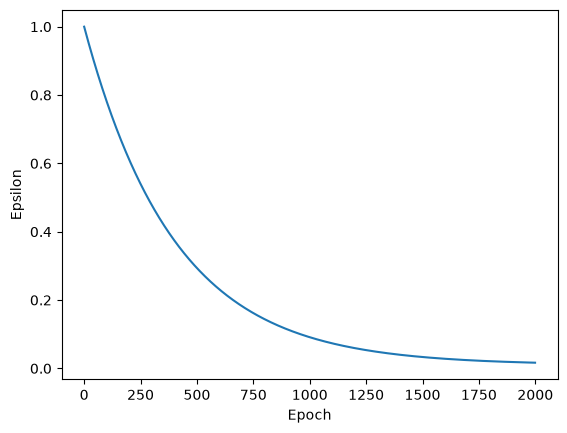

In [122]:
epochs = range(EPOCHS)
eps = [epsilon(epoch) for epoch in epochs]
plt.plot(epochs, eps)
plt.xlabel("Epoch")
plt.ylabel("Epsilon")
plt.show()

## DQN Building Blocks

In [123]:
class DQN(nn.Module):
    def __init__(self, n_hidden: int):
        super().__init__()
        self.fc1 = nn.Linear(4, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 2)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [124]:
State = np.ndarray
Action = int
Reward = float
Done = bool


class ReplayBuffer:
    def __init__(self, buffer_size: int):
        self.buffer = deque(maxlen=buffer_size)

    def is_filled(self):
        return len(self.buffer) == self.buffer.maxlen

    def push(self, transition: tuple[State, Action, Reward, State, Done]) -> None:
        self.buffer.append(transition)

    def sample(self, sample_size: int) -> tuple[State, Action, Reward, State, Done]:
        return random.sample(self.buffer, k=sample_size)

## Train DQN

In [125]:
env = gym.make("CartPole-v1")
replay_buffer = ReplayBuffer(REPLAY_BUFFER_SIZE)
dqn_online = DQN(N_HIDDEN)
dqn_target = DQN(N_HIDDEN)
dqn_target.load_state_dict(dqn_online.state_dict())
criterion = nn.MSELoss()
optimizer = optim.Adam(dqn_online.parameters(), lr=ALPHA)

In [126]:
def batch_2_tensor(
    batch: list[tuple[State, Action, Reward, State, Done]],
) -> tuple[torch.Tensor, ...]:
    states = []
    actions = []
    rewards = []
    next_states = []
    dones = []
    for state, action, reward, next_state, done in batch:
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_state)
        dones.append(done)

    return (
        torch.tensor(np.stack(states)),
        torch.tensor(actions).view(BATCH_SIZE, 1),
        torch.tensor(rewards).view(BATCH_SIZE, 1),
        torch.tensor(np.stack(next_states)),
        torch.tensor(dones, dtype=torch.float32).view(BATCH_SIZE, 1),
    )

In [127]:
losses = []
episode_lengths = []
for epoch in tqdm(range(EPOCHS)):
    state, _ = env.reset(options={"low": -0.1, "high": 0.1})
    done = False
    steps = 0
    while not done:
        # Choose Action
        if random.random() < epsilon(epoch):
            action = int(random.random() > 0.5)
        else:
            with torch.no_grad():
                q = dqn_online(torch.tensor(state))
                action = int(torch.argmax(q))

        # Play Game + Push to Replay Buffer
        next_state, reward, terminated, truncated, _ = env.step(action)
        replay_buffer.push((state, action, reward, next_state, terminated))
        state = next_state
        done = terminated or truncated
        steps += 1

        if not replay_buffer.is_filled():
            continue

        # DQN Inference (Double DQN)
        batch = replay_buffer.sample(BATCH_SIZE)
        state_tensor, action_tensor, reward_tensor, next_state_tensor, done_tensor = (
            batch_2_tensor(batch)
        )
        q = dqn_online(state_tensor)
        with torch.no_grad():
            q_next_online = dqn_online(next_state_tensor)
            q_next_target = dqn_target(next_state_tensor)

        q_next = torch.gather(
            q_next_target, dim=1, index=torch.argmax(q_next_online, dim=1, keepdim=True)
        )
        # Network outputs Q / MAX_Q_VALUE, so q_next is already normalized
        target = (reward_tensor / MAX_Q_VALUE) + GAMMA * q_next * (1 - done_tensor)
        y_hat = torch.gather(q, dim=1, index=action_tensor)

        # DQN Leanring
        loss = criterion(y_hat, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # Update Target DQN (Polyak)
        with torch.no_grad():
            for dqn_online_params, dqn_target_params in zip(
                dqn_online.parameters(), dqn_target.parameters()
            ):
                dqn_target_params.copy_(
                    TAU * dqn_online_params + (1 - TAU) * dqn_target_params
                )

    episode_lengths.append(steps)

100%|██████████| 2000/2000 [06:54<00:00,  4.83it/s]


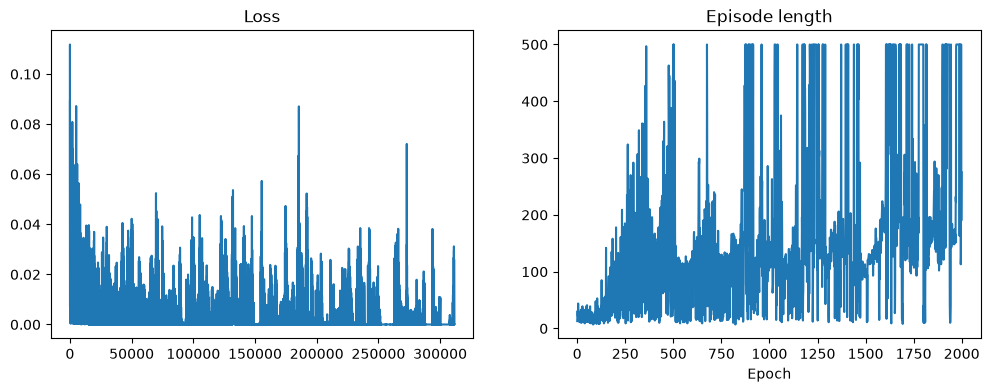

In [130]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses)
ax1.set_title("Loss")
# ax1.set_yscale("log")
ax2.plot(episode_lengths)
ax2.set_title("Episode length")
ax2.set_xlabel("Epoch")
plt.show()

## View Result

In [138]:
simulation = gym.make("CartPole-v1", render_mode="human")
state, _ = simulation.reset(options={"low": -0.1, "high": 0.1})

dqn_online.eval()
terminated = False
steps = 0
while not terminated:
    with torch.no_grad():
        q = dqn_online(torch.tensor(state)) * MAX_Q_VALUE
        print(q)
        action = int(torch.argmax(q))
        state, _, terminated, truncated, _ = simulation.step(action)
        terminated = terminated or truncated
        steps += 1

print(f"Survived {steps} steps")
simulation.close()

tensor([20.2763, 20.1221])
tensor([20.3531, 20.1837])
tensor([20.4394, 20.2551])
tensor([20.5356, 20.3365])
tensor([20.0941, 20.4373])
tensor([20.2866, 20.4447])
tensor([20.3416, 20.4127])
tensor([20.4150, 20.3666])
tensor([20.1694, 20.4833])
tensor([20.2308, 20.4418])
tensor([20.3213, 20.3884])
tensor([20.4413, 20.3230])
tensor([20.2437, 20.4194])
tensor([20.3518, 20.3581])
tensor([20.4522, 20.2888])
tensor([20.3172, 20.3810])
tensor([20.4657, 20.3371])
tensor([20.2845, 20.4407])
tensor([20.4224, 20.4028])
tensor([20.2305, 20.5125])
tensor([20.3572, 20.4813])
tensor([20.5132, 20.4389])
tensor([20.3396, 20.5432])
tensor([20.4844, 20.5069])
tensor([20.6335, 20.4618])
tensor([20.5030, 20.5572])
tensor([20.6661, 20.5144])
tensor([20.4997, 20.6183])
tensor([20.6517, 20.5814])
tensor([20.4740, 20.6914])
tensor([20.6144, 20.6611])
tensor([20.7840, 20.6194])
tensor([20.6240, 20.7240])
tensor([20.7820, 20.6882])
tensor([20.4833, 20.7151])
tensor([20.6158, 20.6768])
tensor([20.7886, 20.6408])
t